In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D, Conv1D, MaxPooling1D
from tensorflow.keras.models import Model

np.random.seed(123)
tf.random.set_seed(123)

In [3]:
from sklearn.metrics import mean_absolute_percentage_error

In [4]:
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [5]:
df = pd.read_csv('airline_passengers.csv', index_col= 'Month', parse_dates = True)

In [6]:
df['LogPassengers'] = np.log(df['Passengers'])

In [7]:
Ntest=12
train = df[:-Ntest]
test = df[-Ntest:]

In [8]:
train_idx = df.index <= train.index[-1]
test_idx = ~train_idx

In [9]:
df['DiffLogPassengers'] = df['LogPassengers'].diff()

In [10]:
''' using differencing, but we could try without differencing as well'''

' using differencing, but we could try without differencing as well'

In [18]:
# ONE STEP FORECASTING

In [11]:
series = df['DiffLogPassengers'].dropna().to_numpy()

T = 10
X = []
Y = []

for t in range(len(series)-T):
    x = series[t:t+T]
    y = series[t+T]
    X.append(x)
    Y.append(y)

X = np.array(X).reshape(-1,T,1) # the data should be NxTxD, hence adding another superficial dimension
Y = np.array(Y)
N = len(X)
print("X.shape:", X.shape,"Y.shape:", Y.shape)

X.shape: (133, 10, 1) Y.shape: (133,)


In [13]:
''' look at the shape of X, its now having an extra dimension to make it N x T x D, previously , in all the codes, we were
using N x T dimentions.
this shows that CNNs are able to automatically scale to multivariate time series - and is multivariate time series ready.
details of this is already mentioned vividly in the notes
'''

' look at the shape of X, its now having an extra dimension to make it N x T x D, previously , in all the codes, we were\nusing N x T dimentions.\nthis shows that CNNs are able to automatically scale to multivariate time series - and is multivariate time series ready.\ndetails of this is already mentioned vividly in the notes\n'

In [14]:
Xtrain, Ytrain = X[:-Ntest], Y[:-Ntest]
Xtest, Ytest = X[-Ntest:], Y[-Ntest:] 

In [16]:
Xtrain.shape

(121, 10, 1)

In [17]:
Xtest.shape

(12, 10, 1)

In [25]:
#CNN
i = Input(shape = (T,1)) # NOTICE THAT IN THE PREVIOUS SECTIONS , WE USED TO MENTION SHAPE = (T,), HERE IT IS (T,D)
# AND D=1 SINCE ITS UNIVARIATE TIME SERIES - THE INPUT STATEMENT EXPECTS SIZE OF EACH SAMPLE
x =  Conv1D(16, 3, activation  = 'relu')(i) # 16 channels/feature maps and kernel size of 3
x = MaxPooling1D(2)(x) # kernel size of 2 and by default, stride of 2 as well
x = Conv1D(32, 3, activation ='relu') (x)
x = GlobalMaxPooling1D()(x)
x = Dense(1)(x)
model =  Model(i,x)

In [26]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 8, 16)          │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 4, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 2, 32)          │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,665 (6.50 KB)

 Trainable params: 1,665 (6.50 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
''' num of parameters in 1st conv1d layer is each filter size (3*1) times num of filters being 16 = (3*1)*16 = 48 + 16 bias =64
num of params in 2nd conv1d layer is each filter size 3*#num of channel of previous layer =3*16 =48
    - num of channels in 2nd conv1d = 32, so num of parameters = 48*32 = 1536 + 32 bias terms = 1568 parameters'''

' num of parameters in 1st conv1d layer is each filter size (3*1) times num of filters being 16 = (3*1)*16 = 48 + 16 bias =64\nnum of params in 2nd conv1d layer is each filter size 3*#num of channel of previous layer =3*16 =48\n    - num of channels in 2nd conv1d = 32, so num of parameters = 48*32 = 1536 + 32 bias terms = 1568 parameters'

In [28]:
model.compile(
    loss = 'mse',
    optimizer = 'adam',
)

In [33]:
r = model.fit(
    Xtrain,
    Ytrain,
    epochs = 1000,
    validation_data = (Xtest, Ytest)
)

Epoch 1/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 2.0904e-04 - val_loss: 0.0049
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 2.0653e-04 - val_loss: 0.0048
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 2.0606e-04 - val_loss: 0.0049
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 2.0579e-04 - val_loss: 0.0049
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 2.0195e-04 - val_loss: 0.0049
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 2.0103e-04 - val_loss: 0.0049
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 2.0144e-04 - val_loss: 0.0048
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 1.9929e-04 - val_loss: 0.0049
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.9947e-04 - val_loss: 0.0049
Epoch 10/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.9648e-04 - val_loss: 0.0049
Epoch 11/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.9397e-04 - val_loss: 0.0049
Epoch 12/1000
4/4 ━

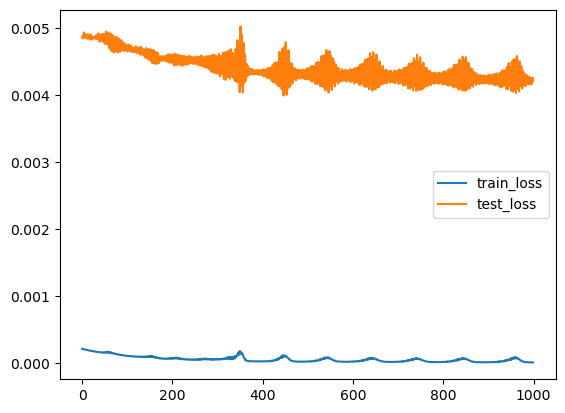

In [34]:
plt.plot(r.history['loss'], label = 'train_loss' )
plt.plot(r.history['val_loss'], label = 'test_loss' )
plt.legend();

In [35]:
train_idx[:T+1] = False # these are non predictable

In [36]:
Ptrain = model.predict(Xtrain).flatten()
Ptest = model.predict(Xtest).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [37]:
df.loc[train_idx, 'Diff Train Prediction'] = Ptrain
df.loc[test_idx, 'Diff Test Prediction'] = Ptest

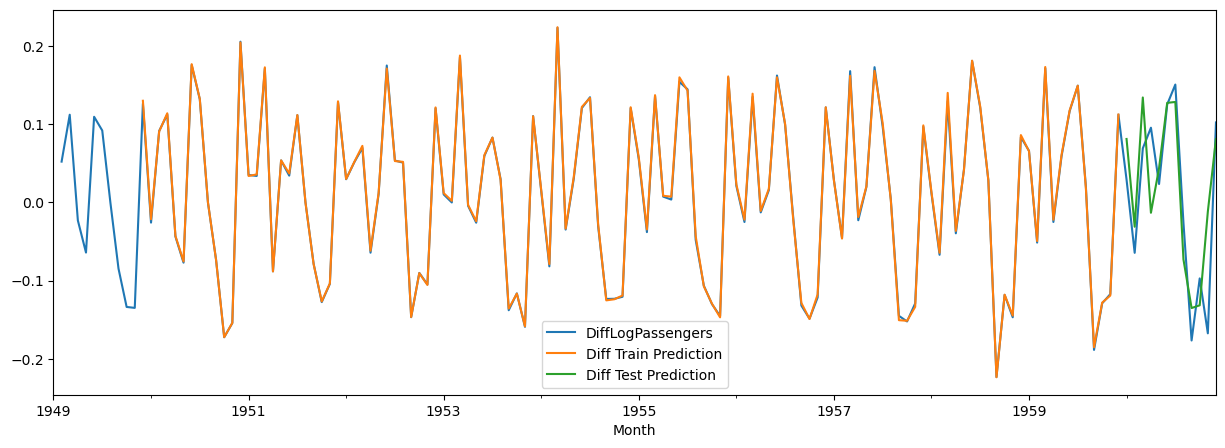

In [38]:
cols = ['DiffLogPassengers','Diff Train Prediction','Diff Test Prediction']
df[cols].plot(figsize =(15,5));

In [39]:
''' high overfitting in the train set above, test predictions look fine'''

' high overfitting in the train set above, test predictions look fine'

In [40]:
# computing un differenced predictions
df['ShiftLogPassengers'] = df['LogPassengers'].shift(1)
prev = df['ShiftLogPassengers']

In [41]:
last_train = train.iloc[-1]['LogPassengers']

In [42]:
# 1step forecast
df.loc[train_idx, '1step_train'] = prev[train_idx] + Ptrain
df.loc[test_idx, '1step_test'] = prev[test_idx] + Ptest

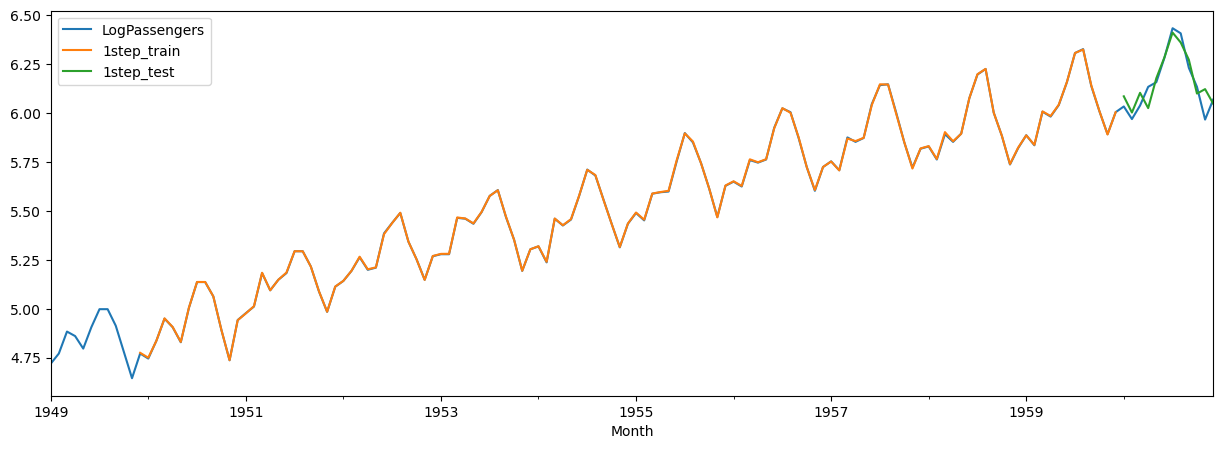

In [43]:
# plot 1 step forecast
df[['LogPassengers','1step_train','1step_test']].plot(figsize =(15,5));

In [44]:
'''looks good but explained earlier that this is not the correct method since data leakage happening in test set.
labels in the 1st row appear as features in the 2nd row, hence model might be able to cheat
'''

'looks good but explained earlier that this is not the correct method since data leakage happening in test set.\nlabels in the 1st row appear as features in the 2nd row, hence model might be able to cheat\n'

In [50]:
print(Xtest.shape)
print(Xtest[0].shape)

(12, 10, 1)
(10, 1)


In [49]:
# testing some code
xyz = Xtest[0]
print (xyz)
xyz = np.roll(xyz, -1)
print(xyz)
print(xyz[-1])

[[ 0.17154242]
 [-0.02493895]
 [ 0.0588405 ]
 [ 0.11672427]
 [ 0.1492963 ]
 [ 0.01987419]
 [-0.18842242]
 [-0.12891387]
 [-0.11716897]
 [ 0.11224286]]
[[-0.02493895]
 [ 0.0588405 ]
 [ 0.11672427]
 [ 0.1492963 ]
 [ 0.01987419]
 [-0.18842242]
 [-0.12891387]
 [-0.11716897]
 [ 0.11224286]
 [ 0.17154242]]
[0.17154242]


In [51]:
#multistep forecast
multistep_predictions = []
last_x = Xtest[0]

while len(multistep_predictions) < Ntest:
    p = model.predict(last_x.reshape(1,-1, 1))[0] # notice that the reshape is now changed to make the data (NxTxD), previously we used to reshape (1, -1)
    multistep_predictions.append(p)

    last_x = np.roll(last_x, -1)
    last_x[-1] = p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [52]:
df.loc[test_idx, 'multistep'] = last_train + np.cumsum(multistep_predictions)

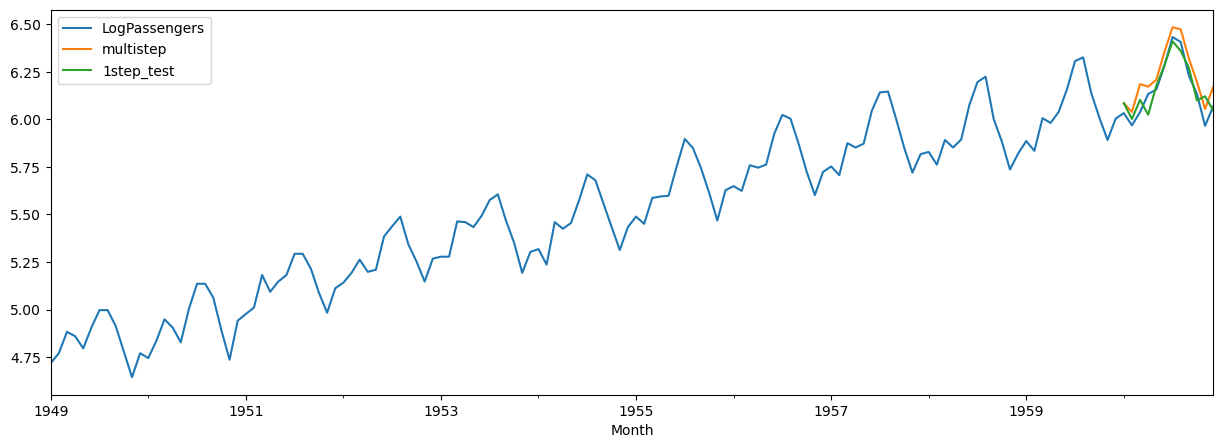

In [53]:
df[['LogPassengers','multistep','1step_test']].plot(figsize =(15,5));

In [54]:
''' multistep seems to be overestimating than the 1 step'''

' multistep seems to be overestimating than the 1 step'

In [55]:
# multi output supervised 
Tx = T
Ty = Ntest
X = []
Y = []

for t in range(len(series) - Tx -Ty + 1):
    x = series[t:t+Tx]
    X.append(x)
    y = series[t+Tx:t+Tx+Ty] 
    Y.append(y)

X = np.array(X).reshape(-1, Tx, 1) # notice that we have reshaped the data here to be N X T X D
Y = np.array(Y).reshape(-1, Ty)
N = len(X)
print("X.shape",X.shape, "Y.shape", Y.shape)

X.shape (122, 10, 1) Y.shape (122, 12)


In [56]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [58]:
Xtrain_m.shape, Ytrain_m.shape

((121, 10, 1), (121, 12))

In [60]:
Xtest_m.shape, Ytest_m.shape

((1, 10, 1), (1, 12))

In [61]:
#CNN
i = Input(shape = (Tx,1))
x =  Conv1D(16, 3, activation  = 'relu')(i) 
x = MaxPooling1D(2)(x) 
x = Conv1D(32, 3, activation ='relu') (x)
x = GlobalMaxPooling1D()(x)
x = Dense(Ty)(x)
model =  Model(i,x)

In [62]:
model.compile(loss='mse', optimizer='adam')

In [63]:
r = model.fit(
    Xtrain_m,
    Ytrain_m,
    epochs = 200,
    validation_data = (Xtest_m, Ytest_m)
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0115 - val_loss: 0.0116
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0110 - val_loss: 0.0117
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0107 - val_loss: 0.0115
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0104 - val_loss: 0.0112
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0102 - val_loss: 0.0107
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0100 - val_loss: 0.0102
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0097 - val_loss: 0.0098
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0095 - val_loss: 0.0094
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0092 - val_loss: 0.0090
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0090 - val_loss: 0.0086
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0087 - val_loss: 0.0082
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0084 - val_lo

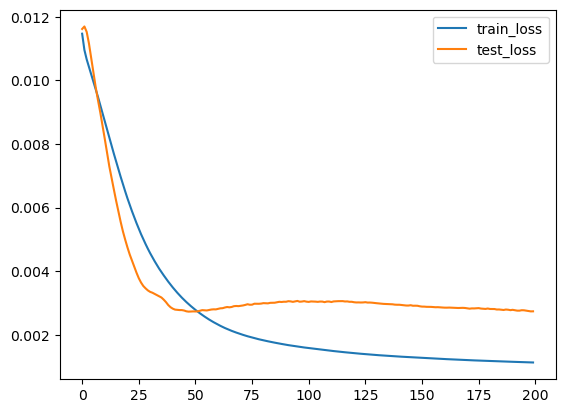

In [64]:
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'test_loss')
plt.legend();

In [65]:
Ptrain = model.predict(Xtrain_m)
Ptest = model.predict(Xtest_m)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [66]:
Ptrain.shape, Ptest.shape

((121, 12), (1, 12))

In [67]:
Ptrain = Ptrain[:,0] # keeping the closest predictions closer to current time since we believe it to be more accurate

In [68]:
# this is how the original Ptrain was - we just took the 1st column
# y1, y2, y3
# y2, y3, y4
# y3, y4, y5

In [69]:
print(Ptest)
print(Ptest[0])  # just grabbing the 0th row - no more rows since test has only 1 row of data
Ptest = Ptest[0]

[[ 0.01519573 -0.05077021  0.14169975 -0.03896189  0.04933258  0.17001823
   0.10051496  0.02134131 -0.18541601 -0.12027506 -0.1356661   0.09070221]]
[ 0.01519573 -0.05077021  0.14169975 -0.03896189  0.04933258  0.17001823
  0.10051496  0.02134131 -0.18541601 -0.12027506 -0.1356661   0.09070221]


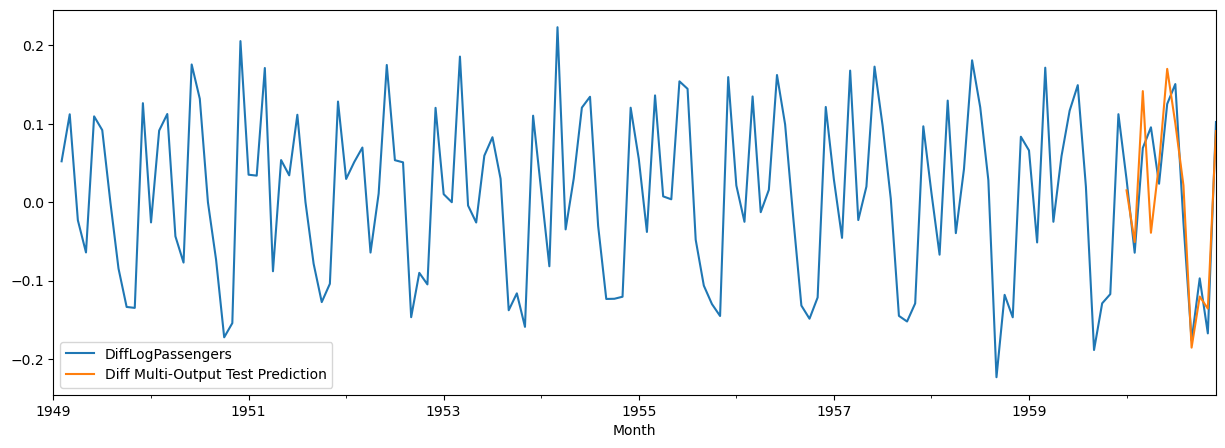

In [70]:
df.loc[test_idx, 'Diff Multi-Output Test Prediction'] = Ptest
cols = ['DiffLogPassengers','Diff Multi-Output Test Prediction']
df[cols].plot(figsize=(15,5));

In [71]:
''' predictions look fine'''

' predictions look fine'

In [72]:
df.loc[test_idx, 'multioutput'] = last_train + np.cumsum(Ptest)

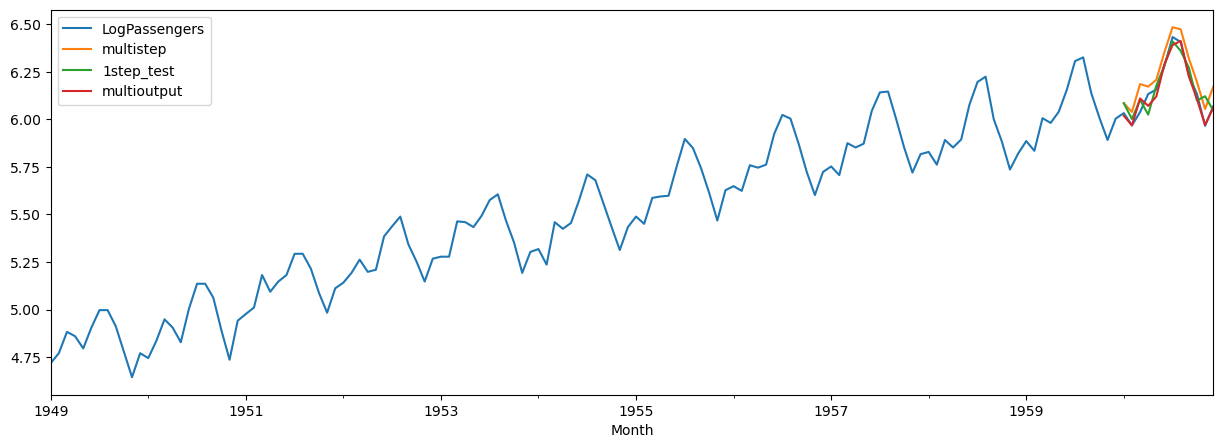

In [73]:
df[['LogPassengers','multistep','1step_test','multioutput']].plot(figsize =(15,5));

In [74]:
''' multioutput looks pretty good'''

' multioutput looks pretty good'

In [75]:
test_log_pass = df.iloc[-Ntest:]['LogPassengers']
mape1 =  mean_absolute_percentage_error(test_log_pass, df.loc[test_idx, 'multistep'])
mape2 =  mean_absolute_percentage_error(test_log_pass, df.loc[test_idx, 'multioutput'])
print("multistep MAPE:", mape1)
print("multioutput MAPE:", mape2)

multistep MAPE: 0.012157809134534086
multioutput MAPE: 0.003832608454956605


In [76]:
''' we can also see if logging, differencing is necessary,optimizing for lags etc?
Also, walkforward validation is necessary to see which hyperaparameters are the best and produce consistently better result'''

' we can also see if logging, differencing is necessary,optimizing for lags etc?\nAlso, walkforward validation is necessary to see which hyperaparameters are the best and produce consistently better result'